In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('datasets\\dengue.csv')
df

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [7]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Month          1020 non-null   object
 1   Year           1020 non-null   int64 
 2   Region         1020 non-null   object
 3   Dengue_Cases   1020 non-null   int64 
 4   Dengue_Deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

In [4]:
df.isnull().sum()

Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

<h4>The dataset is already clean.</h4>
<p>Let us proceed with EDA.</p>

<h1> DENGUE CASES TREND FROM 2016 - 2020 </h1>

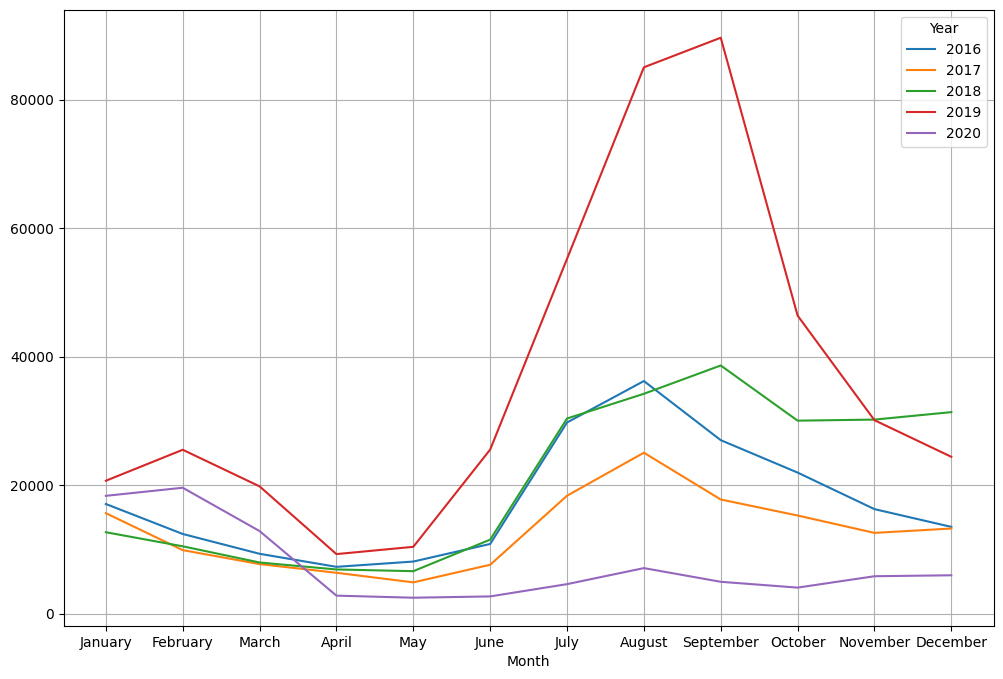

In [10]:
#list
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

monthly_cases = df.groupby(["Month", "Year"])["Dengue_Cases"].sum()

monthly_cases.unstack().plot(kind='line')
plt.gcf().set_size_inches(12,8)
plt.grid(True)
plt.xticks(range(0,12), month_order)
plt.show()

<h1> Group the Regions into Islands </h1>

In [50]:
# Define region groupings
luzon_regions = [
    "Region I", "Region II", "Region III", "Region IV-A", "MIMAROPA",
    "Region V", "NCR", "CAR"
]
visayas_regions = [
    "Region VI", "Region VII", "Region VIII"
]
mindanao_regions = [
    "Region IX", "Region X", "Region XI", "Region XII",
    "Region XIII", "BARMM"
]

# Function to assign island group
def assign_island_group(region):
    if region in luzon_regions:
        return "Luzon"
    elif region in visayas_regions:
        return "Visayas"
    elif region in mindanao_regions:
        return "Mindanao"
    else:
        return "Unknown"

# Apply the function to your DataFrame
df["Island_Group"] = df["Region"].apply(assign_island_group)
df.loc[df["Region"] == "Region IV-B", "Island_Group"] = "Luzon"

<h1> Mortality Rate per each Region </h1>

In [51]:
Regional_Death = df.groupby(["Region"])[['Dengue_Deaths', 'Dengue_Cases']].sum().reset_index()
# Avoid division by zero and handle missing values
Regional_Death["Mortality_Rate"] = np.where(
    Regional_Death["Dengue_Cases"] > 0,
    np.round((Regional_Death["Dengue_Deaths"] / Regional_Death["Dengue_Cases"]) * 100, 2),
    np.nan  # or 0 if you prefer to fill with zero
)

In [52]:
Regional_Death

,Region,Dengue_Deaths,Dengue_Cases,Mortality_Rate
0,BARMM,332,11537,2.88
1,CAR,1008,30582,3.30
2,NCR,4008,115966,3.46
3,Region I,157,59066,0.27
4,Region II,193,45141,0.43
5,Region III,482,131064,0.37
6,Region IV-A,652,163029,0.40
7,Region IV-B,130,30849,0.42
8,Region IX,532,47781,1.11
9,Region V,185,22167,0.83


In [56]:
# Group by Island_Group and calculate mortality rate per 1,000 people
island_mortality = (
    df.groupby("Island_Group")[["Dengue_Deaths", "Dengue_Cases"]]
    .sum()
    .assign(Mortality_Rate=lambda x: np.round((x["Dengue_Deaths"] / x["Dengue_Cases"]) * 1000, 2))
)
island_mortality

,Dengue_Deaths,Dengue_Cases,Mortality_Rate
Island_Group,,,
Luzon,6815,597864,11.40
Mindanao,5859,269372,21.75
Visayas,4170,280189,14.88
